Importing Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [74]:
df = pd.read_csv('/content/train.csv')

In [75]:
df.head() #inspect data before doing anything

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [76]:
df.shape

(891, 12)

In [77]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [78]:
df.info()
# here look data types of each column, which column contain missing values which contain numbers

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [79]:
df.describe() # statistics of numerical columns

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [80]:
df.isnull().sum() # missing values create problem to train ml models

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Now understanding the target

In [81]:
df['Survived'].value_counts()

,count
Survived,
0,549
1,342


Visualize the target

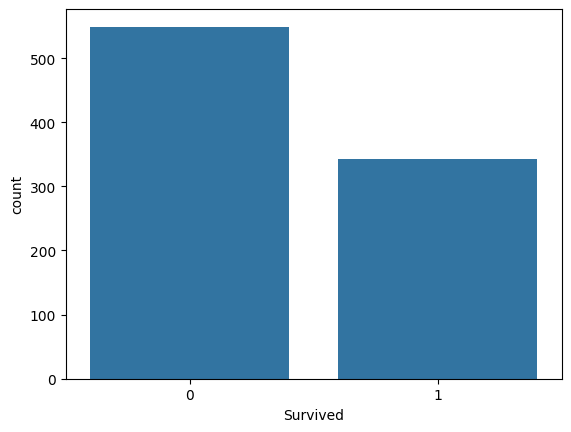

In [82]:
sns.countplot(x='Survived',data=df)
plt.show() # is the data balanced or imbalanced ?

what factors effected the survival ? and we cannot say answer to this question just like that to do so we have to find the patterns in the given data i.e (Exploratory Data Analysis)

Survival rate

In [83]:
survival_rate = df['Survived'].mean()
print(survival_rate)

0.3838383838383838


Survival by gender

In [84]:
df.groupby('Sex')['Survived'].mean() # this showing that female are the most among the survivers

,Survived
Sex,
female,0.742038
male,0.188908


Let's visualize this

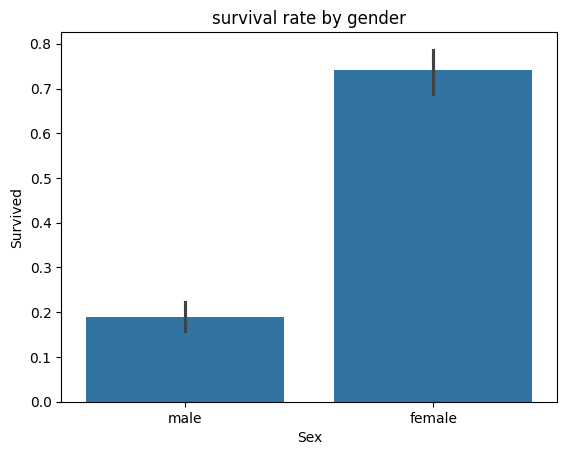

In [85]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('survival rate by gender')
plt.show()

survival by passenger class

In [86]:
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


visualize

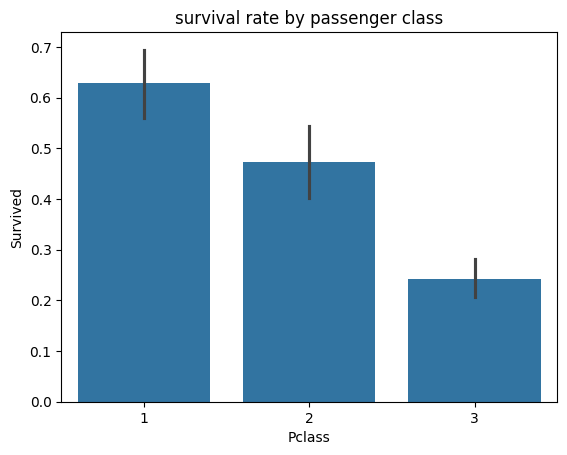

In [87]:
sns.barplot(x='Pclass',y='Survived',data=df)
plt.title('survival rate by passenger class')
plt.show()

Age Distribution

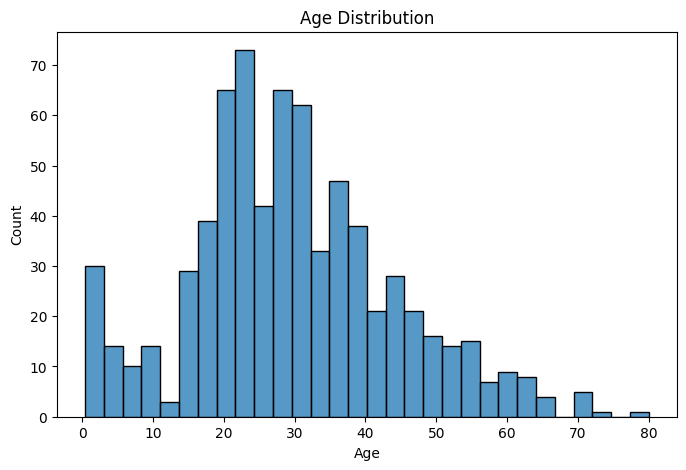

In [88]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')
plt.show() # most passsengers lie in which age group

Fare distibution

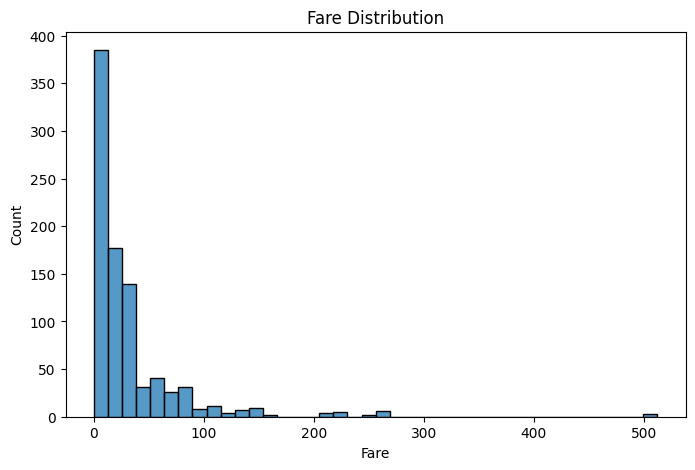

In [89]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=40)
plt.title('Fare Distribution')
plt.show() # most passengers pain low fair and very few paid high fair price

Survival by age

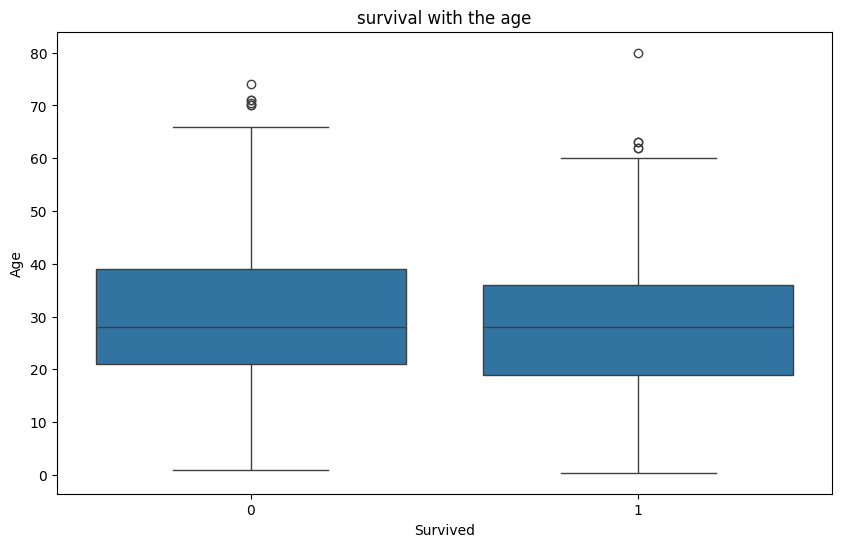

In [90]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived',y='Age',data=df)
plt.title('survival with the age')
plt.show() # 1 is little down compared to 0 shows that younger passsengers survival little more

survival by fare

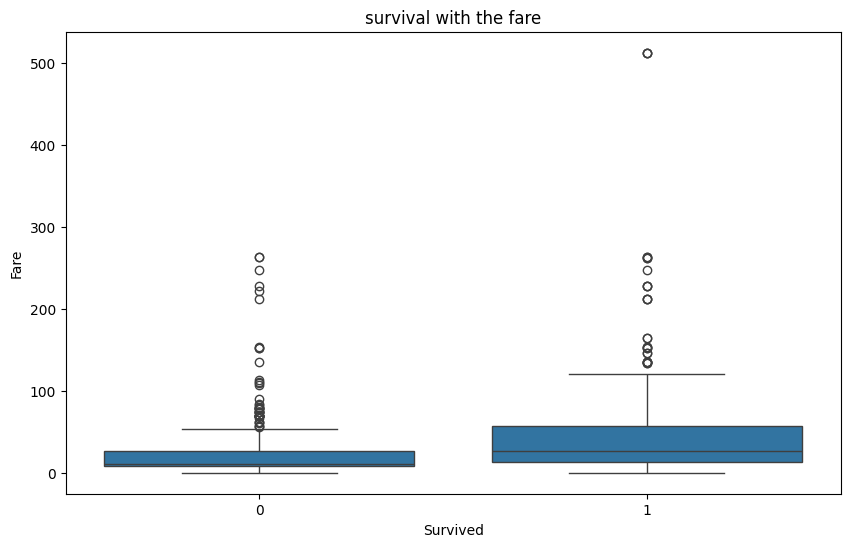

In [91]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Survived',y='Fare',data=df)
plt.title('survival with the fare')
plt.show() # people who paying better have higher survival chances

Survival by embarkation port

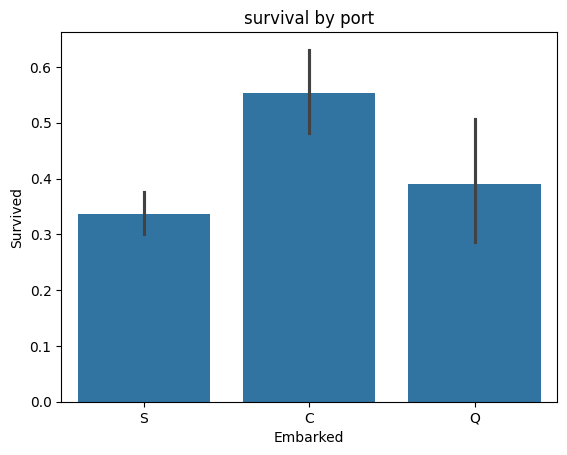

In [92]:
sns.barplot(x='Embarked', y='Survived',data=df)
plt.title('survival by port')
plt.show()

Correlation matrix ---make sure columns choosen are numerical if not we will get error

In [93]:
numeric_df = df.select_dtypes(include=np.number)

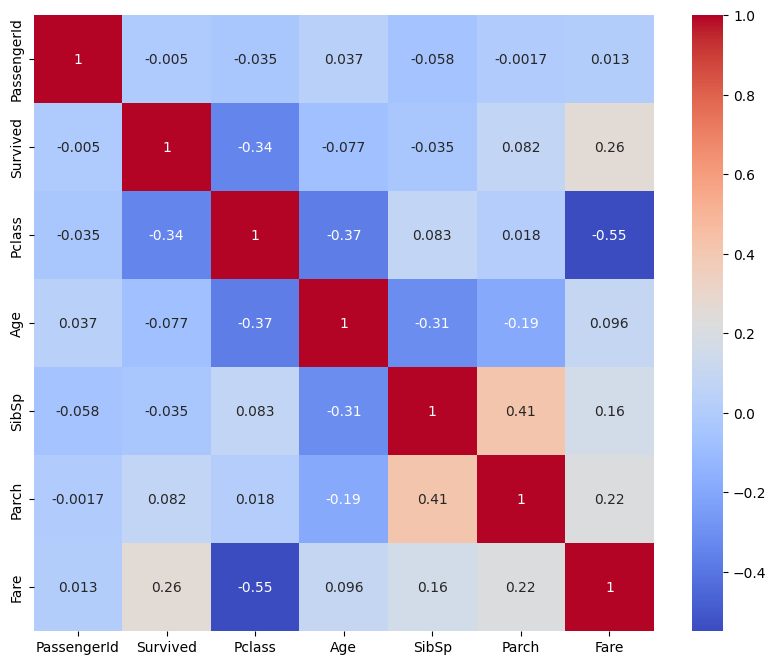

In [94]:
plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show() # Fare is possitivly correlated and Pclass is negatively correlated

which features relate to survival

In [95]:
numeric_df.corr()['Survived'].sort_values(ascending=False)

,Survived
Survived,1.000000
Fare,0.257307
Parch,0.081629
PassengerId,-0.005007
SibSp,-0.035322
Age,-0.077221
Pclass,-0.338481


missing values review
if more values we remove the column and very few we replace with mean, median, mode

In [96]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Data preprocessing now we will convert data to the format that machine learning models can understand

In [97]:
df_clean = df.copy()

removing cabin as it has many missing values

In [98]:
df_clean.drop('Cabin',axis=1,inplace=True)

In [99]:
df_clean.drop('PassengerId',axis=1,inplace=True)

In [100]:
df_clean.drop('Ticket',axis=1,inplace=True)

In [101]:
df_clean.drop('Name',axis=1,inplace=True)

In [102]:
df_clean.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


Missing age values are replaces with median as it is more robust to outliers

In [103]:
df_clean['Age'].fillna(
    df_clean['Age'].median(),
    inplace=True
)

/tmp/ipykernel_2091/2641206672.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(


In [104]:
df_clean['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipykernel_2091/355879631.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [105]:
df_clean.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


Now converting text to numbers ---> ml model cannot understand text

In [106]:
df_clean['Sex'] = df_clean['Sex'].map({
    'male': 0,
    'female':1
})

In [107]:
df_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


In [108]:
df_clean['Embarked'].value_counts()

,count
Embarked,
S,646
C,168
Q,77


In [109]:
df_clean['Embarked'] = df_clean['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

In [110]:
df_clean.head() # now everything looks clean

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


Sepearating Features and Target

In [111]:
x = df_clean.drop('Survived',axis=1)

In [112]:
y = df_clean['Survived']

In [113]:
print(x.shape)
print(y.shape)

(891, 7)
(891,)


Train test split

In [114]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [115]:
print(x_train.shape)
print(x_test.shape)

(712, 7)
(179, 7)


Feature scaling -- more helpfull in logestic regression

In [116]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # fit only training data otherwise dataleakage happens

In [117]:
x_train_scaled = scaler.fit_transform(x_train)

In [118]:
x_test_scaled = scaler.transform(x_test)

importing logistic regression

In [119]:
from sklearn.linear_model import LogisticRegression

In [120]:
model = LogisticRegression()

In [121]:
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [122]:
y_prediction = model.predict(x_test_scaled)


In [123]:
print('Actual Values: ')
print(y_test.head(10).values)
print('\nPredicted values: ')
print(y_prediction[:10])

Actual Values: 
[1 0 0 1 1 1 1 0 1 1]

Predicted values: 
[0 0 0 1 1 1 1 0 1 1]


calculate accuracy

In [124]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_prediction,y_test)
print(score)

0.7988826815642458


Confusion matrics

In [125]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_prediction)
print(cm)

[[89 16]
 [20 54]]


visualize confusion matrix ---> one of the most important ml predictive metrice visualization

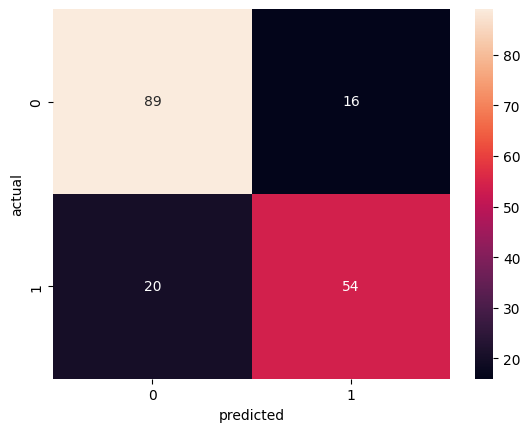

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(
    cm,
    annot=True,
    fmt = 'd'
)
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [127]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_prediction))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



precission = when model predicted survived how often is it correct

high precision means few false alarms

recall= out of all survivers how many did we found

f1 score = precision + recall



Feature Importance(Let's see which feature influence the prediction's) Interpretation

In [128]:
importance = pd.DataFrame({
    'Feature':x.columns,
    'Coefficient':model.coef_[0]
})
importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
1,Sex,1.270916
5,Fare,0.143666
6,Embarked,0.140339
4,Parch,-0.089298
3,SibSp,-0.359839
2,Age,-0.404834
0,Pclass,-0.804272


so sex if most influential and after that fare is possitive ans Pclass is also more as it is most negative

female are more likely to be survived

lower class higher the chance of survival

higher the fare high is survival chances

predict one passenger manually

In [129]:
x_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
709,3,0,28.0,1,1,15.2458,1
439,2,0,31.0,0,0,10.5000,0
840,3,0,20.0,0,0,7.9250,0
720,2,1,6.0,0,1,33.0000,0
39,3,1,14.0,1,0,11.2417,1


In [130]:
sample = [[1, 1, 25, 0, 0, 80, 1]]
sample_scaled = scaler.transform(sample)
prediction = model.predict(sample_scaled)
print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Import Random Forest

In [131]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random forest does not require feature scaling unlike logistic regression

In [132]:
rf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [133]:
rf_pred = rf.predict(x_test)

Evaluate Accuracy

it is better than logistic regression

In [134]:
from sklearn.metrics import accuracy_score
rf_score = accuracy_score(y_test,rf_pred)
print('Random Forest Accuracy : ',rf_score)

Random Forest Accuracy :  0.8268156424581006


classification report

In [135]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



confusion matrix

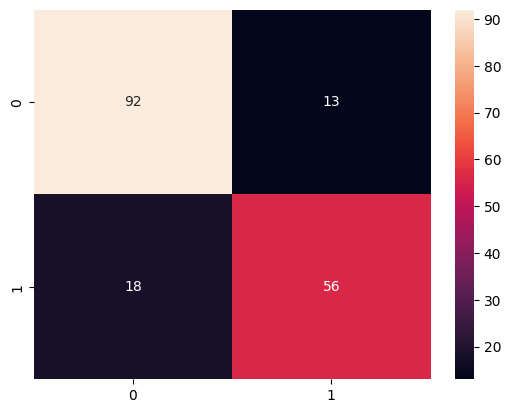

In [136]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,rf_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)
plt.show()

In [137]:
print("Logistic Regression Accuracy:", score)

print("Random Forest Accuracy:", rf_score)

Logistic Regression Accuracy: 0.7988826815642458
Random Forest Accuracy: 0.8268156424581006


In [138]:
importance = pd.DataFrame({
    'Feature':x.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending=False
)
print(importance)

    Feature  Importance
5      Fare    0.269744
1       Sex    0.268418
2       Age    0.256426
0    Pclass    0.081891
3     SibSp    0.052077
4     Parch    0.037390
6  Embarked    0.034054


Visualize Feature Importance

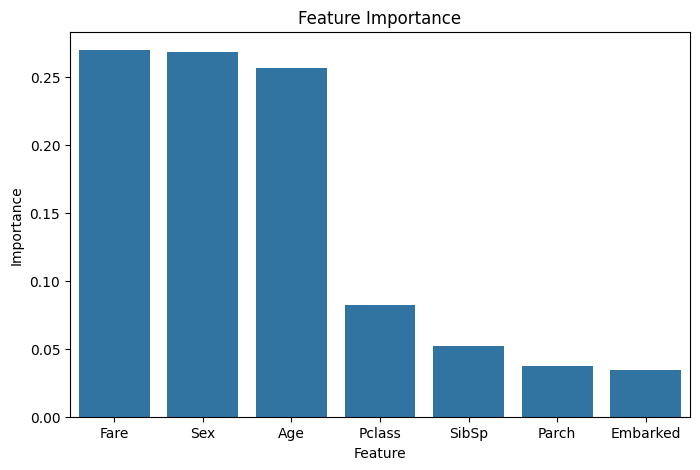

In [139]:
plt.figure(figsize=(8,5))
sns.barplot(
    x = 'Feature',
    y = 'Importance',
    data=importance
)
plt.title('Feature Importance')
plt.show()

Cross Validation ---- insted of one train split we can evaluate multiple times

In [ ]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf,
    x,
    y,
    cv=5
)
print(scores)
print('Average accuracy :',scores.mean())


Hyperparemeter tuning

In [ ]:
rf2 = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 5,
    random_state=42
)
rf2.fit(x_test,y_test)
pred2 = rf2.predict(x_test)
rf_score2 = accuracy_score(y_test,pred2)
print('Accuracy of Random Foret after hyperparemetrisation : ',rf_score2)

accuracy of the model increased a lot due to hyperparameterisation

experiment with max_depth, n_estimators, min_sample_splits

In [ ]:
import joblib

In [ ]:
joblib.dump(
    rf,
    'titanic_model.pkl'
)

In [ ]:
model = joblib.load(
    'titanic_model.pkl'
)